In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [37]:
# Load dataset
# skipping 90 rows because fun header information at the top
df = pd.read_csv("TESS_project_candidates.csv", skiprows=90)

# List of columns to drop Alot of these are error and
columns_to_drop = [
    'rowid', 'tid', 'pl_pnum', 'ctoi_alias', 'toi_created', 'rowupdate',
    'rastr', 'ra', 'decstr', 'dec', 'decerr1', 'decerr2',
    'st_pmra', 'st_pmraerr1', 'st_pmraerr2', 'st_pmralim', 'st_pmrasymerr',
    'st_pmdec', 'st_pmdecerr1', 'st_pmdecerr2', 'st_pmdeclim', 'st_pmdecsymerr',
    'pl_tranmid', 'pl_tranmiderr1', 'pl_tranmiderr2', 'pl_tranmidlim', 'pl_tranmidsymerr',
    'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbpersymerr',
    'pl_trandurh', 'pl_trandurherr1', 'pl_trandurherr2', 'pl_trandurhlim', 'pl_trandurhsymerr',
    'pl_trandep', 'pl_trandeperr1', 'pl_trandeperr2', 'pl_trandeplim', 'pl_trandepsymerr',
    'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radesymerr',
    'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_insolsymerr',
    'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'pl_eqtsymerr',
    'st_tmagerr1', 'st_tmagerr2', 'st_tmaglim', 'st_tmagsymerr',
    'st_disterr1', 'st_disterr2', 'st_distlim', 'st_distsymerr',
    'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_teffsymerr',
    'st_loggerr1', 'st_loggerr2', 'st_logglim', 'st_loggsymerr',
    'st_raderr1', 'st_raderr2', 'st_radlim', 'st_radsymerr'
]

'''
# columns kept for analysis

  pl_orbper: Orbital period (important for planet characteristics).
  pl_rade: Planet radius.
  pl_insol: Planetary insolation (important for habitability studies).
  pl_eqt: Equilibrium temperature.
  st_dist: Stellar distance (important for understanding the environment of the planets).
  st_teff: Stellar effective temperature.
  st_logg: Stellar log surface gravity.
  st_rad: Stellar radius.
    '''

# Drop the unnecessary columns
df_cleaned = df.drop(columns=columns_to_drop)

df = df_cleaned

In [28]:
df.describe()





,toi,toipfx,raerr1,raerr2,pl_orbper,pl_rade,pl_insol,st_tmag,st_dist,st_teff,st_logg,st_rad
count,7358.000000,7358.000000,0.0,0.0,7256.000000,6874.000000,7202.000000,7358.000000,7147.000000,7214.000000,6542.000000,6874.000000
mean,3585.072736,3585.062245,NaN,NaN,17.993210,10.324896,2254.521765,11.527877,475.692040,5798.666507,4.305184,1.407948
std,2055.197058,2055.197409,NaN,NaN,98.481552,8.655134,10719.704497,1.637732,566.010695,1500.071273,0.305602,1.629440
min,101.010000,101.000000,NaN,NaN,0.152076,0.552507,0.000342,4.627800,6.531270,2808.000000,0.100000,0.114827
25%,1788.260000,1788.250000,NaN,NaN,2.460728,4.399826,85.967076,10.359500,176.400500,5205.850000,4.123918,0.890000
50%,3567.510000,3567.500000,NaN,NaN,4.078383,10.504180,365.852081,11.781250,360.072000,5801.500000,4.330000,1.240000
75%,5372.760000,5372.750000,NaN,NaN,7.906320,14.045700,1174.535000,12.837675,642.938000,6303.650000,4.500000,1.660810
max,7175.010000,7175.000000,NaN,NaN,1837.889731,297.111726,280833.000000,18.332400,14728.300000,50000.000000,5.960650,102.030000


In [29]:
print("Shape of the dataset:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Shape of the dataset: (7358, 13)
Number of rows: 7358
Number of columns: 13


In [30]:
# https://science.nasa.gov/universe/exoplanets/discovery-alert-tess-finds-its-first-earth-sized-planet/

print("Columns in the dataset:")
print(list(df.columns))

Columns in the dataset:
['toi', 'toipfx', 'tfopwg_disp', 'raerr1', 'raerr2', 'pl_orbper', 'pl_rade', 'pl_insol', 'st_tmag', 'st_dist', 'st_teff', 'st_logg', 'st_rad']


In [31]:
print("Summary statistics of numerical columns:")
print(df.describe())

Summary statistics of numerical columns:
               toi       toipfx  raerr1  raerr2    pl_orbper      pl_rade  \
count  7358.000000  7358.000000     0.0     0.0  7256.000000  6874.000000   
mean   3585.072736  3585.062245     NaN     NaN    17.993210    10.324896   
std    2055.197058  2055.197409     NaN     NaN    98.481552     8.655134   
min     101.010000   101.000000     NaN     NaN     0.152076     0.552507   
25%    1788.260000  1788.250000     NaN     NaN     2.460728     4.399826   
50%    3567.510000  3567.500000     NaN     NaN     4.078383    10.504180   
75%    5372.760000  5372.750000     NaN     NaN     7.906320    14.045700   
max    7175.010000  7175.000000     NaN     NaN  1837.889731   297.111726   

            pl_insol      st_tmag       st_dist       st_teff      st_logg  \
count    7202.000000  7358.000000   7147.000000   7214.000000  6542.000000   
mean     2254.521765    11.527877    475.692040   5798.666507     4.305184   
std     10719.704497     1.6377

In [32]:
print("Missing data in each column:")
print(df.isnull().sum())


Missing data in each column:
toi               0
toipfx            0
tfopwg_disp       2
raerr1         7358
raerr2         7358
pl_orbper       102
pl_rade         484
pl_insol        156
st_tmag           0
st_dist         211
st_teff         144
st_logg         816
st_rad          484
dtype: int64


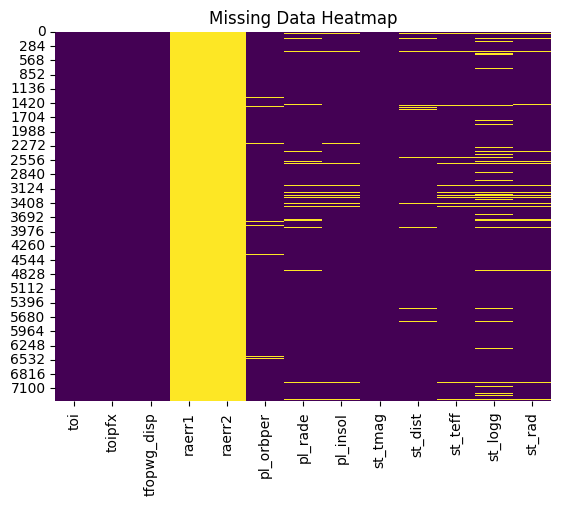

In [33]:
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

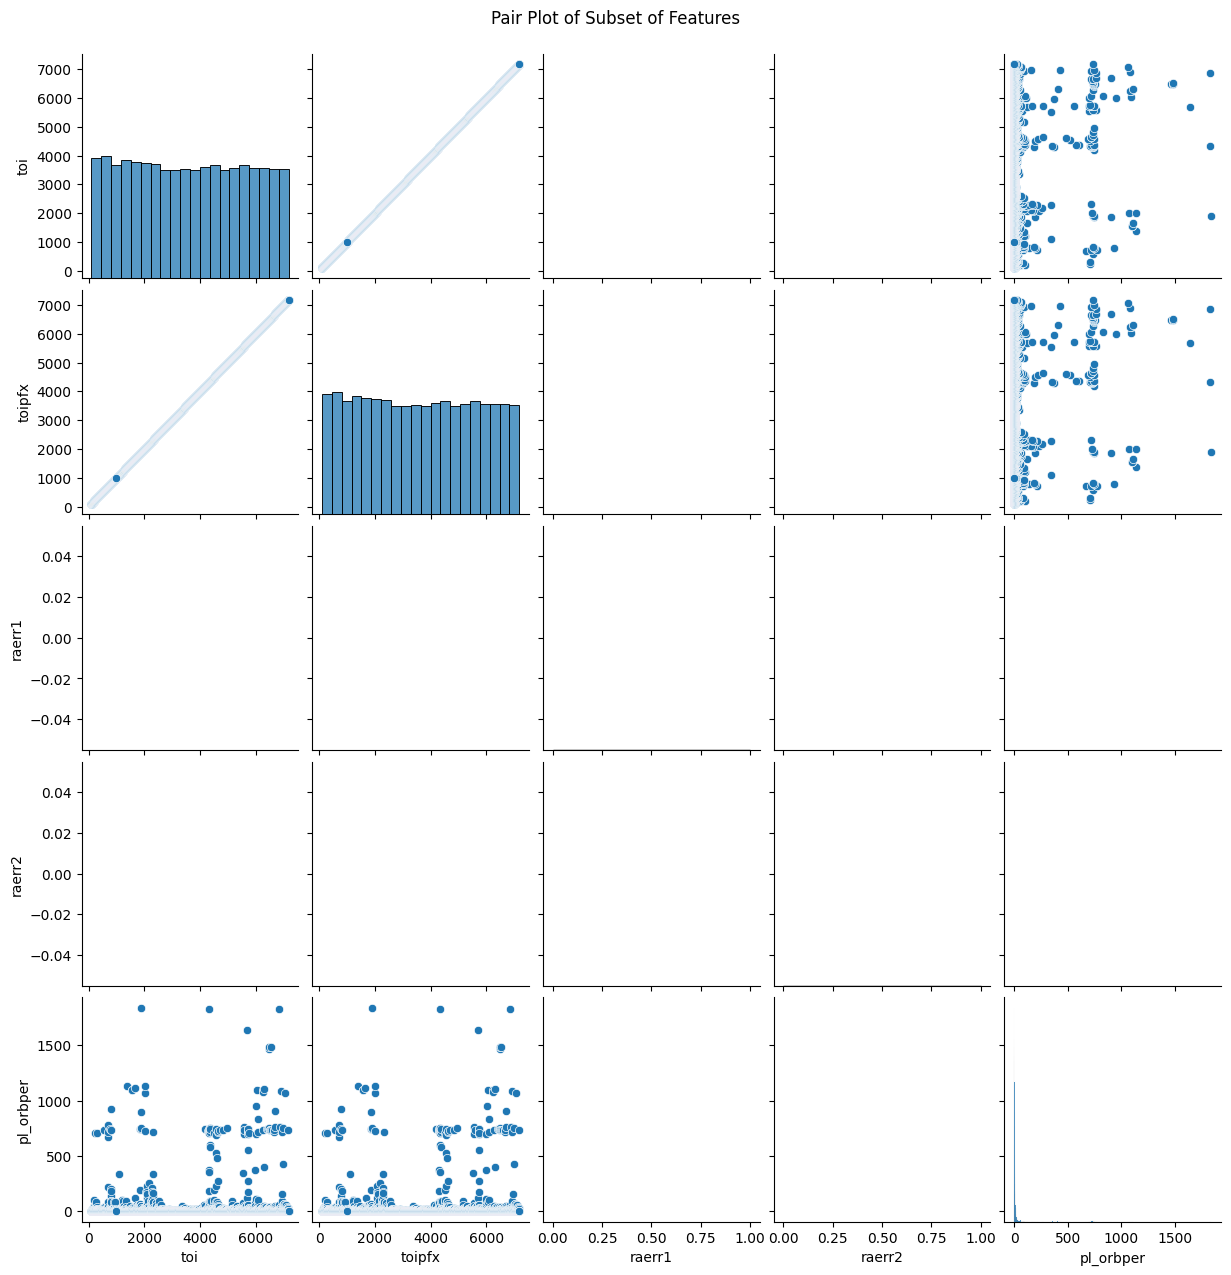

In [34]:
# Select a subset of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns[:5]  # Select first 5 numerical columns
sns.pairplot(df[numerical_cols])
plt.suptitle("Pair Plot of Subset of Features", y=1.02)
plt.show()

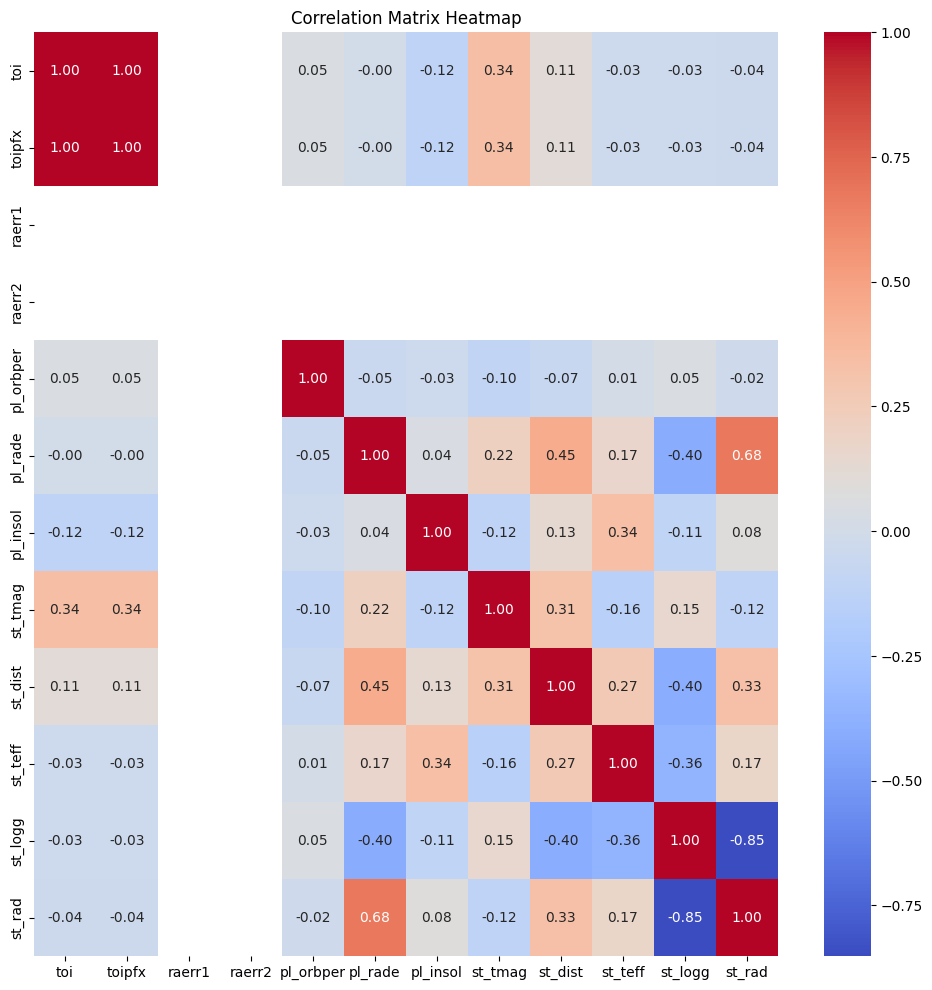

In [35]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=np.number)

# Calculate correlation matrix for numerical columns
corr_matrix = numerical_cols.corr()

# Plot the heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()


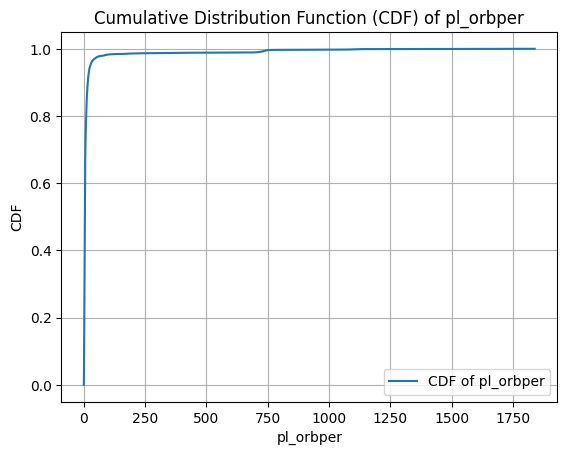

In [36]:
# Select the column for which we want to plot the CDF
data_column = 'pl_orbper'

# Sort the data in ascending order and compute the cumulative probability
sorted_data = np.sort(df[data_column].dropna())
cdf = np.arange(len(sorted_data)) / len(sorted_data)

# Plot the CDF
plt.plot(sorted_data, cdf, label=f'CDF of {data_column}')
plt.xlabel(data_column)
plt.ylabel("CDF")
plt.title(f"Cumulative Distribution Function (CDF) of {data_column}")
plt.legend()
plt.grid()
plt.show()
